# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

https://github.com/cr2003/BK_DeepLearning_with_Python_3ed



<a href="file:///C:/Users/crodr/OneDrive/InterChange/Books/Tech/DeepLearnig/Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf" target="_blank">Abrir PDF Local</a>

In [ ]:
import os

# Definimos la ruta de tu libro
ruta_libro = r"C:\Users\crodr\OneDrive\InterChange\Books\Tech\DeepLearnig\Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf"

# Esto le dice a Windows: "Abre este archivo con el programa por defecto del sistema"
os.startfile(ruta_libro)

In [1]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch04


In [2]:
!python --version

Python 3.12.10


In [3]:
import os

os.environ["KERAS_BACKEND"] = "jax"

# Chapter 04 - Classification and regression

## 4.3 Predicting house prices: A regression example

The two previous examples were considered `classification` problems, where the goal
was to predict a single discrete label of an input data point. Another common type of
machine learning problem is `regression`, which consists of predicting a continuous value
instead of a discrete label: for instance, predicting the temperature tomorrow given
meteorological data, or predicting the time that a software project will take to complete
given its specifications.

**NOTE** Confusingly, `logistic regression` isn’t a regression algorithm—it’s a `classification` algorithm.

### 4.3.1 The California Housing Price dataset

You’ll attempt to predict the median price of homes in different areas of California,
based on data from the 1990 census.

Each data point in the dataset represents information about a “block group,” a group
of homes located in the same area. You can think of it as a district. This dataset has two
versions, the “small” version with just 600 districts, and the “large” version with 20,640
districts. Let’s use the small version, because real-world datasets can often be tiny, and
you need to know how to handle such cases.

For each district, we know

* The longitude and latitude of the approximate geographic center of the area.

* The median age of houses in the district.

* The population of the district. The districts are pretty small: the average population
is 1,425.5.

* The total number of households.

* The median income of those households.

* The total number of rooms in the district, across all homes located there. This is
typically in the low thousands.

* The total number of bedrooms in the district.

That’s eight variables in total (longitude and latitude count as two variables). The goal
is to use these variables to predict the median value of the houses in the district. Let’s
get started by loading the data.

In [ ]:
# Listing 4.24 Loading the California Housing Prices dataset

from keras.datasets import california_housing

# Make sure to pass version="small" to get the right data
(train_data, train_targets), (test_data, test_targets) = california_housing.load_data(
    version="small"
)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


Let's look at the data:

In [5]:
train_data.shape

(480, 8)

In [6]:
test_data.shape

(120, 8)

As you can see, we have 480 training samples and 120 test samples, each with 8 numerical
features. The targets are the median values of homes in the district considered, in
dollars:

In [7]:
train_targets

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

The prices are between $60,000 and $500,000. If that sounds cheap, remember that
this was in 1990, and these prices aren’t adjusted for inflation.

### 4.3.2 Preparing the data

It would be problematic to feed into a neural network values that all take wildly different
ranges. The model might be able to automatically adapt to such heterogeneous
data, but it would definitely make learning more difficult. A widespread best practice
to deal with such data is to do feature-wise normalization: for each feature in the input
data (a column in the input data matrix), you subtract the mean of the feature and
divide by the standard deviation, so that the feature is centered around 0 and has a unit
standard deviation. This is easily done in NumPy.

In [13]:
# Listing 4.25 Normalizing the data

mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

Note that the quantities used for normalizing the test data are computed using the
training data. You should never use in your workflow any quantity computed on the
test data, even for something as simple as data normalization.
In addition, we should also scale the targets. Our normalized inputs have their value
in a small range close to 0, and our model’s weights are initialized with small random
values. This means that our model’s prediction will also be small values when we start
training. If the targets are in the range 60,000–500,000, the model is going to need very
large weight values to output those. With a small learning rate, it would take a very long
time to get there. The simplest fix is to divide all target values by 100,000, so that the
smallest target becomes 0.6, and the largest becomes 5. We can then convert the model’s
predictions back to dollar values by multiplying them by 100,000 accordingly.

In [14]:
# Listing 4.26 Scalling the targets

y_train = train_targets / 100_000
y_test = test_targets / 100_000


### 4.3.3 Building your model
Because so few samples are available, you’ll use a very small model with two intermediate
layers, each with 64 units. In general, the less training data you have, the worse
overfitting will be, and using a small model is one way to mitigate overfitting.

In [15]:
# Listing 4.27 Model definiton

import keras
from keras import layers


def get_model():
    # Because you need to instantiate the same model multiple times,
    # you use a function to construct it
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )

    model.compile(
        optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"]
    )
    return model

The model ends with a single unit and no activation: it will be a linear layer. This is
a typical setup for `scalar regression`—a regression where you’re trying to predict a
single continuous value. Applying an activation function would constrain the range
the output can take; for instance, if you applied a `sigmoid` activation function to
the last layer, the model could only learn to predict values between 0 and 1. Here,
because the last layer is purely linear, the model is free to learn to predict values in
any range.

Note that you compile the model with the `mean_squared_error` loss function—mean
squared error, the square of the difference between the predictions and the targets. This
is a widely used loss function for regression problems.

You’re also monitoring a new metric during training: mean absolute error (`MAE`).

It’s the absolute value of the difference between the predictions and the targets. For
instance, an MAE of 0.5 on this problem would mean your predictions are off by $50,000
on average (remember the target scaling of factor 100,000).

### 4.3.4 Validating your approach using K-fold validation

To evaluate your model while you keep adjusting its parameters (such as the number
of epochs used for training), you could split the data into a training set and a validation
set, as you did in the previous examples. But because you have so few data points, the
validation set would end up being very small (for instance, about 100 examples). As a
consequence, the validation scores might change a lot depending on which data points
you chose to use for validation and which you chose for training: the validation scores
might have a high variance with regard to the validation split. This would prevent you
from reliably evaluating your model.

The best practice in such situations is to use `K-fold` cross-validation (see figure 4.9).
It consists of splitting the available data into K partitions (typically K = 4 or 5), instantiating
K identical models, and training each one on K – 1 partitions while evaluating on
the remaining partition. The validation score for the model used is then the average of
the K validation scores obtained. In terms of code, this is straightforward.

<img src="../pics/fig_4_9.png" width=800> 


In [16]:
# Listing 4.28 K-fold validation
import numpy as np

k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    # Prepares the validation data: data from partition #k
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]

    # Prepares the trainin data: data from all other partitions
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )

    # Build the Keras model (already compile)
    model = get_model()

    # Trains the Keras model
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )

    # Evaluates the model on the validation data
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)


Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


Running this with `num_epochs` = 50 yields the following results:

In [17]:
[round(value, 3) for value in all_scores]

[0.31, 0.297, 0.271, 0.317]

In [18]:
round(np.mean(all_scores), 3)

np.float64(0.299)

The different runs do indeed show meaningfully different validation scores, from
0.271 to 0.317. The average (0.299) is a much more reliable metric than any single
score—that’s the entire point of K-fold cross-validation. In this case, you’re off by
$29,600 on average, which is significant considering that the prices range from $60,000
to $500,000.

Let’s try training the model a bit longer: 200 epochs. To keep a record of how well
the model does at each epoch, you’ll modify the training loop to save the per-epoch
validation score log.

In [ ]:
# Listing 4.29 Saving the validation logs at each fold

k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    # Prepares the validation data: data from partition #k
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]

    # Prepares the trainin data: data from all other partitions
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )

    # Build the Keras model (already compile)
    model = get_model()

    # Trains the Keras model
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)


Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


You can then compute the average of the per-epoch mean absolute error (MAE) scores
for all folds.

In [20]:
# Listing 4.30 Building the history of successive mean K-fold validation scores

average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

Let’s plot this; see figure 4.10.

<function matplotlib.pyplot.show(close=None, block=None)>

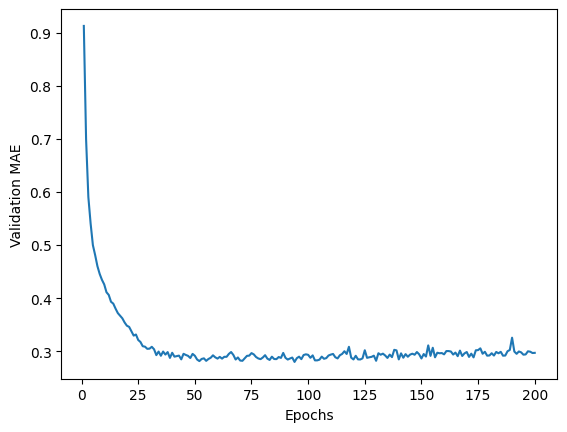

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show

**Figure 4.10 Validation MAE by epoch**

It may be a little difficult to read the plot due to a scaling issue: the validation MAE for
the first few epochs is dramatically higher than the values that follow. Let’s omit the
first 10 data points, which are on a different scale than the rest of the curve.

In [22]:
# Listing 4.32 Plotting validation scores excluding the first 10 data points

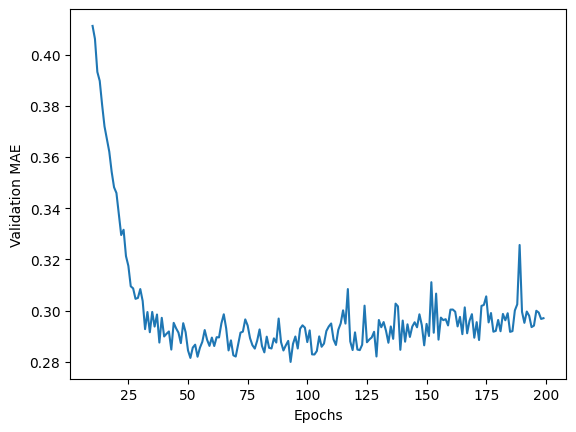

In [23]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)

plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

**Figure 4.11 Validation MAE by epoch, excluding the first 10 data points**

According to this plot (see figure 4.11), validation MAE stops improving significantly
after 120–140 epochs (this number includes the 10 epochs we omitted). Past that
point, you start overfitting.
Once you’re finished tuning other parameters of the model (in addition to the number
of epochs, you could also adjust the size of the intermediate layers), you can train a
final production model on all of the training data, with the best parameters, and then
look at its performance on the test data.

In [ ]:
# Listing 4.33 Training the final model

model = get_model()  # Gets a fresh, compiled model
# Trains it on the entirety od the data
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3460 - mean_absolute_error: 0.3470


Here’s the final result:

In [28]:
round(test_mean_absolute_error, 2)

0.35

### 4.3.5 Generating predictions on new data
When calling `predict()` on our binary classification model, we retrieved a scalar score
between 0 and 1 for each input sample. With our multiclass classification model, we
retrieved a probability distribution over all classes for each sample. Now, with this scalar
regression model, `predict()` returns the model’s guess for the sample’s price in
hundreds of thousands of dollars:

In [30]:
predictions = model.predict(x_test)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([2.4244668], dtype=float32)

The first district in the test set is predicted to have an average home price of about
$242,000.